In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
df = pd.read_csv("customer_shopping.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [11]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

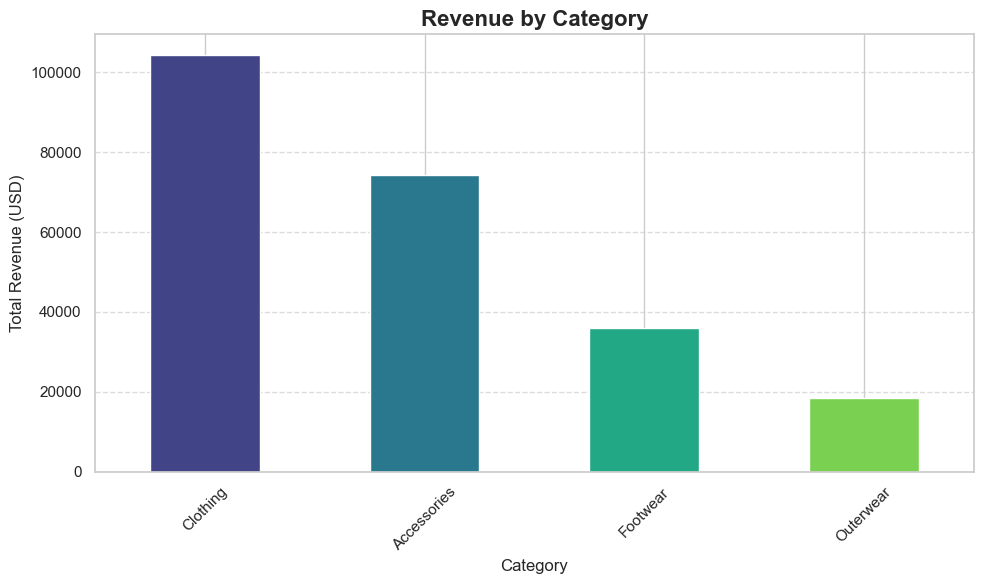

In [26]:
plt.figure(figsize=(10,6))

category_sales.plot(
    kind='bar',
    color=sns.color_palette("viridis", len(category_sales))
)

plt.title("Revenue by Category", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Revenue (USD)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

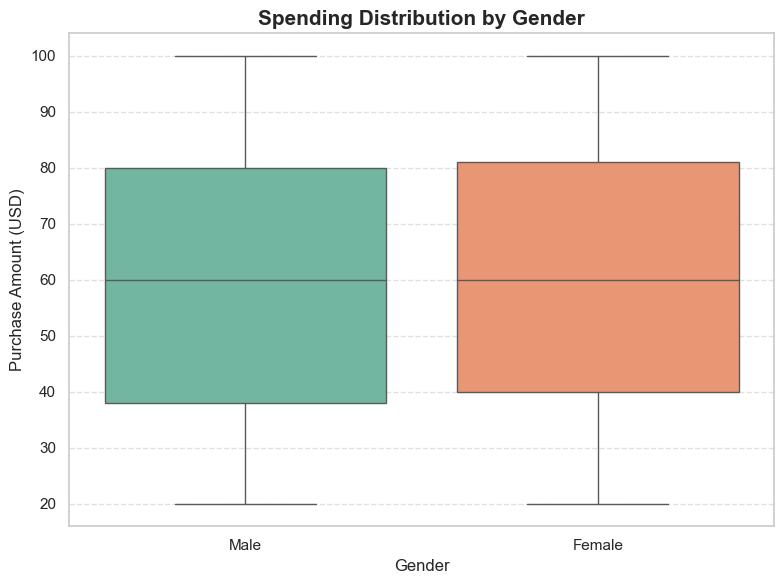

In [28]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='gender',
    y='purchase_amount_usd',
    hue='gender',          # assign hue
    data=df,
    palette='Set2',
    legend=False           # remove duplicate legend
)

plt.title("Spending Distribution by Gender", fontsize=15, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Purchase Amount (USD)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

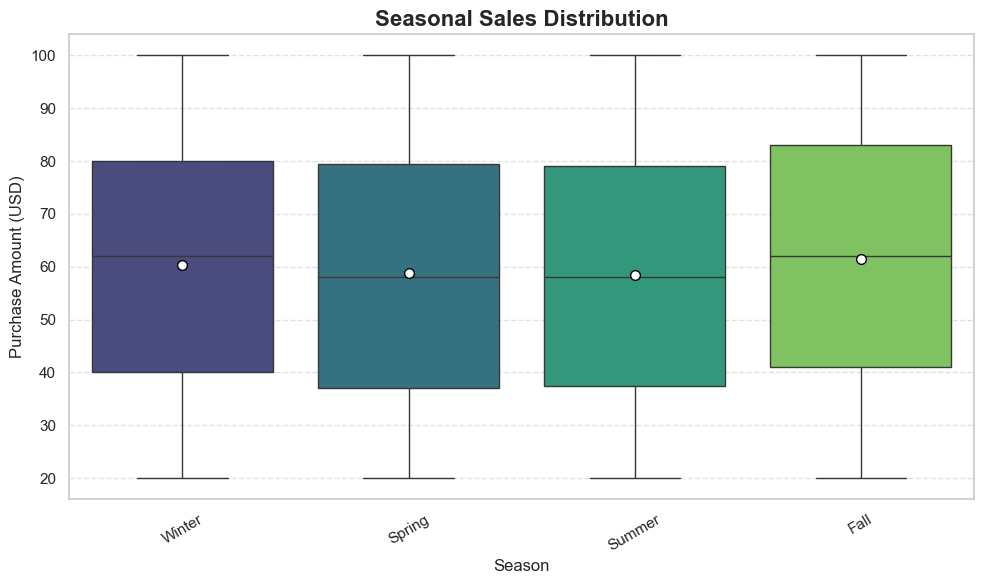

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='season',
    y='purchase_amount_usd',
    hue='season',          # required for palette (new seaborn)
    data=df,
    palette='viridis',
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    },
    legend=False
)

plt.title("Seasonal Sales Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Purchase Amount (USD)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

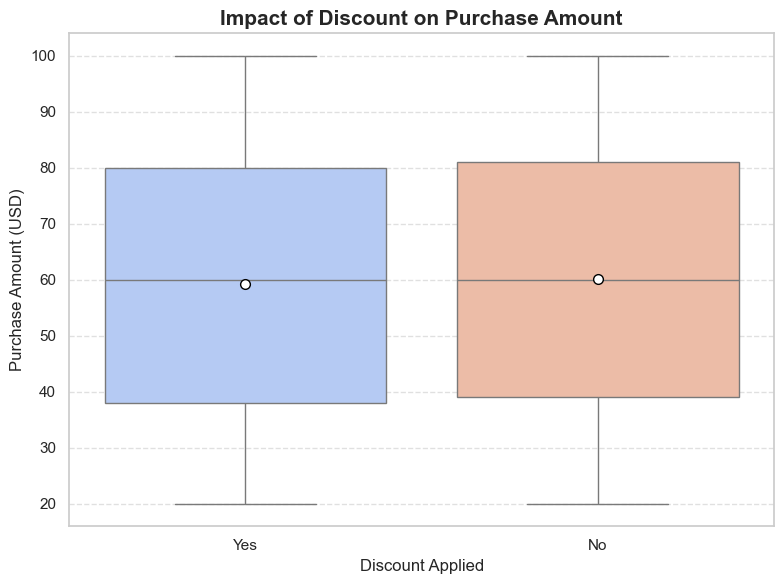

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='discount_applied',
    y='purchase_amount_usd',
    hue='discount_applied',   # required for palette
    data=df,
    palette='coolwarm',
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    },
    legend=False
)

plt.title("Impact of Discount on Purchase Amount", fontsize=15, fontweight='bold')
plt.xlabel("Discount Applied", fontsize=12)
plt.ylabel("Purchase Amount (USD)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

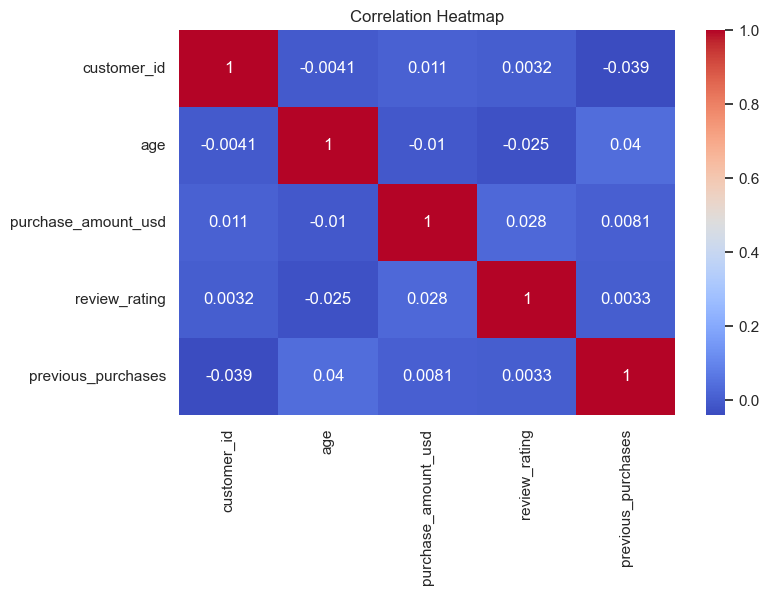

In [17]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
customer_total = df.groupby('customer_id')['purchase_amount_usd'].sum().reset_index()

customer_total.rename(columns={'purchase_amount_usd': 'total_spent'}, inplace=True)

customer_total.head()

,customer_id,total_spent
0,1,53
1,2,64
2,3,73
3,4,90
4,5,49


In [20]:
threshold = df['purchase_amount_usd'].mean()

df['high_spender'] = df['purchase_amount_usd'].apply(lambda x: 1 if x > threshold else 0)

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_encoded.drop('high_spender', axis=1)
y = df_encoded['high_spender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest with class balancing
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       408
           1       1.00      1.00      1.00       372

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780


Confusion Matrix:

[[408   0]
 [  0 372]]


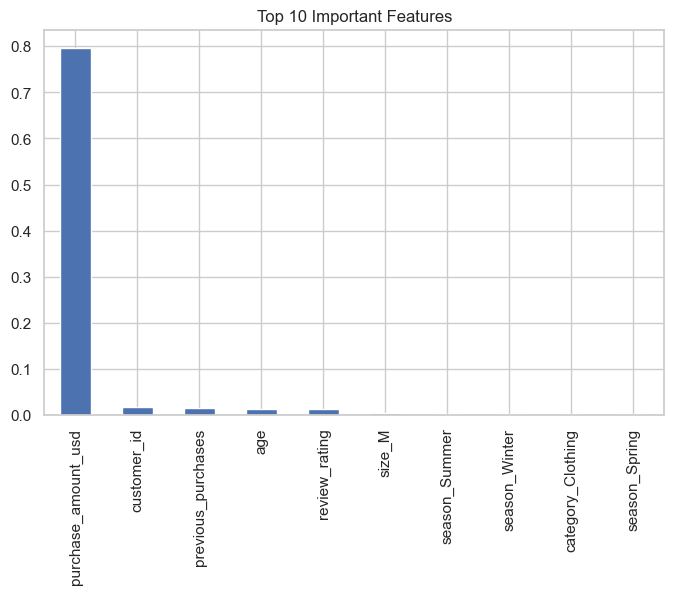

In [40]:


feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

print("Logistic Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

Logistic Accuracy: 0.9769230769230769


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_pred = model.predict(X_test)
lr_pred = lr.predict(X_test)

comparison = {
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, lr_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, lr_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, lr_pred, zero_division=0)
    ]
}

results_df = pd.DataFrame(comparison)

results_df

C:\Users\JIYA JAIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.000000,1.000000,1.0,1.000000
1,Logistic Regression,0.476923,0.476923,1.0,0.645833


<Figure size 800x600 with 0 Axes>

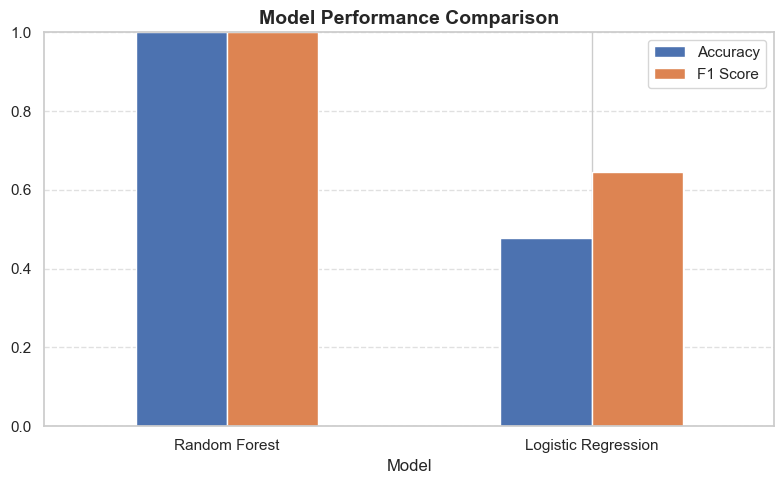

In [50]:
plt.figure(figsize=(8,6))

results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.ylim(0,1)
plt.title("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()